In [29]:
import seaborn as sns 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score

In [4]:
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [32]:
# Feature Selection

features = ["pclass", "sex", "age", "embarked", "fare"]
target = ["survived"]

In [33]:
# Missing data

from sklearn.impute import SimpleImputer

imp_mean = SimpleImputer(strategy="mean")
titanic[["age"]] = imp_mean.fit_transform(titanic[["age"]]) # SimpleImputer takes values as a 2D array

imp_frequent = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_frequent.fit_transform(titanic[["embarked"]])

In [34]:
# Feature Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [35]:
# Model training

X = titanic[features]
y = titanic[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42)

from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier().fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))

Accuracy:  0.753731343283582
Precision:  0.6991150442477876


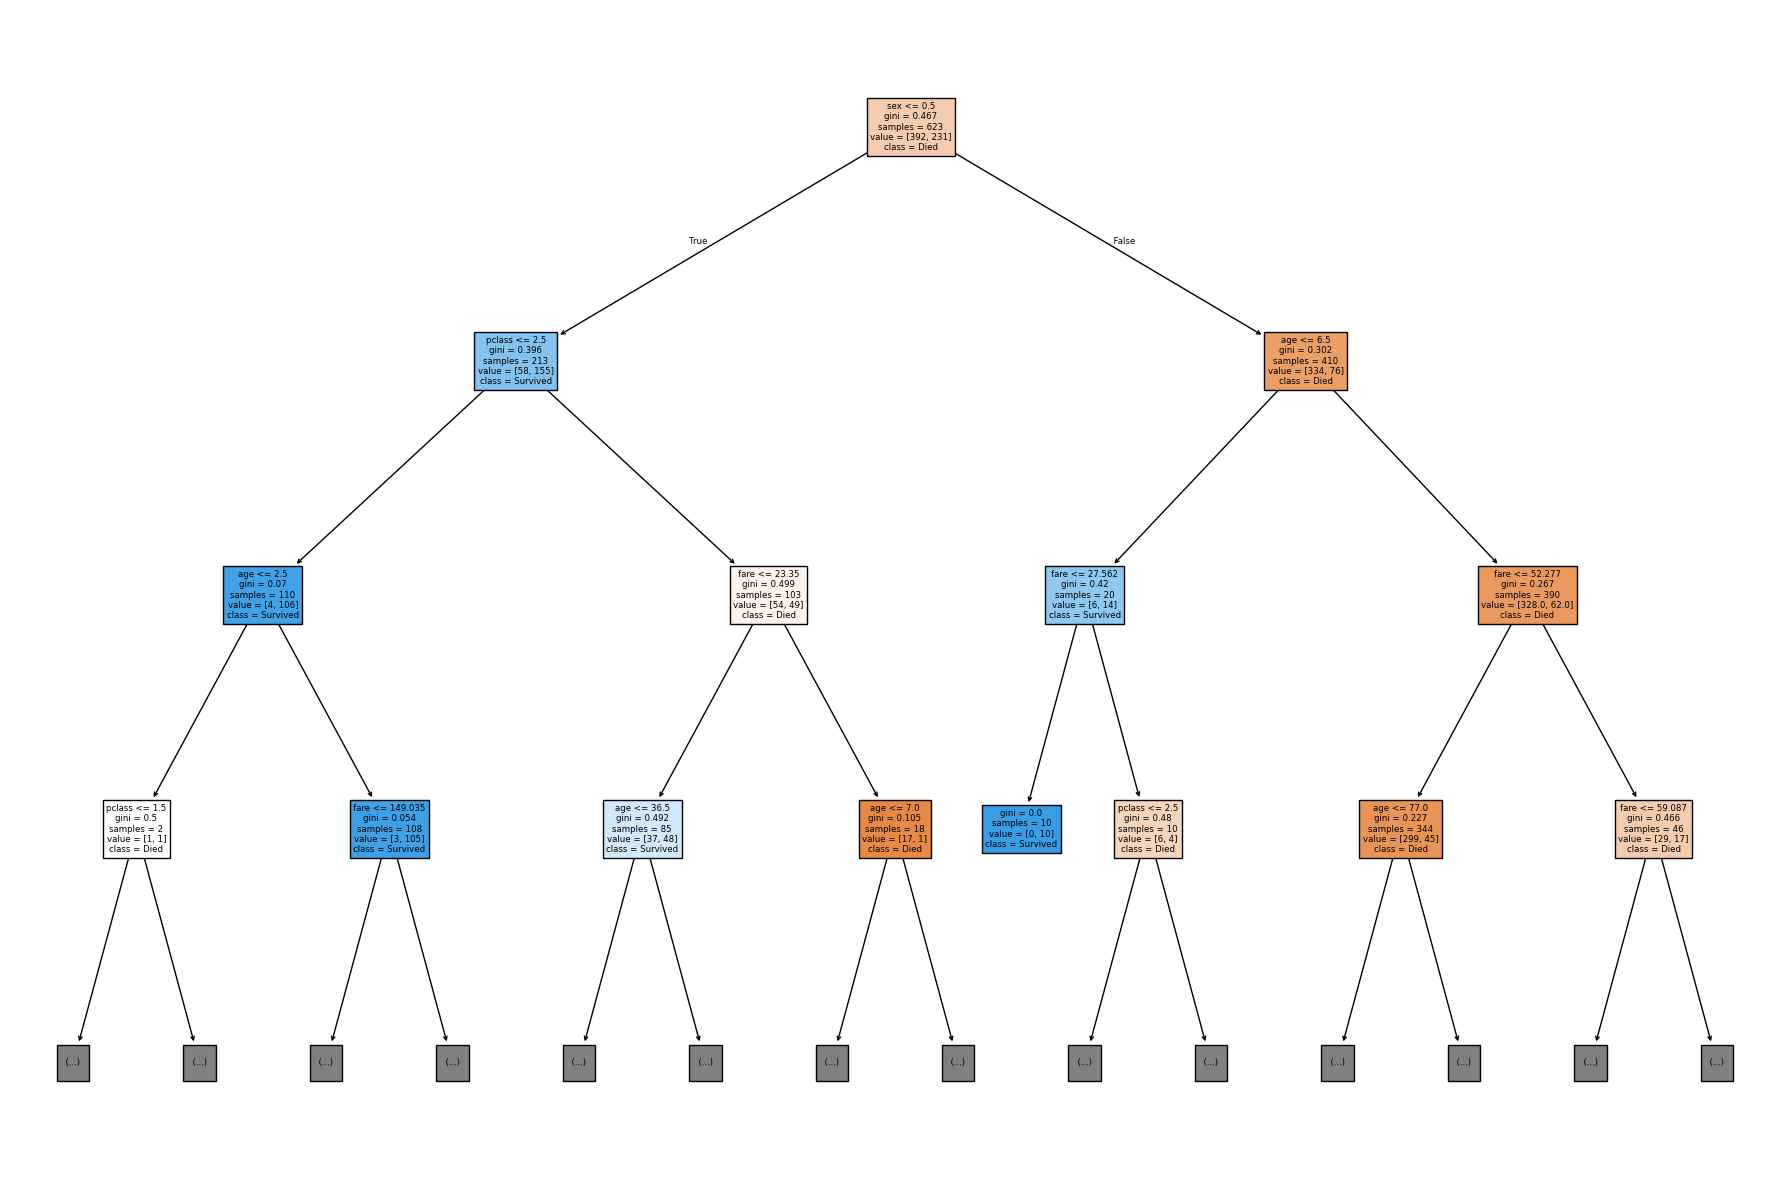

In [ ]:
# Decision Tree- no pruning
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 12))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
    max_depth=3
)

plt.tight_layout()
plt.show()

In [ ]:
# Pre-pruning

